In [ ]:
# Importing necessary libraries
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import warnings

In [4]:
# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

In [ ]:
from pathlib import Path

# Convert string paths to Path objects
BASE_DIR = Path(r'C:\Users\ADVIK\Downloads\shl-intern-hiring-assessment')
TRAIN_AUDIO_DIR = BASE_DIR / 'Dataset' / 'audios' / 'train'
TEST_AUDIO_DIR = BASE_DIR / 'Dataset' / 'audios' / 'test'
TRAIN_CSV = BASE_DIR / 'train.csv'
TEST_CSV = BASE_DIR / 'test.csv'
SAMPLE_RATE = 22050  # Standard sample rate for speech analysis
DURATION = 45  # Minimum duration in seconds
N_MFCC = 13  # Number of MFCC coefficients to extract


In [18]:
# Load the data
train_df = pd.read_csv("C:/Users/ADVIK/Downloads/shl-intern-hiring-assessment/Dataset/train.csv")
test_df = pd.read_csv("C:/Users/ADVIK/Downloads/shl-intern-hiring-assessment/Dataset/test.csv")

In [19]:
# Display dataset info
print(f"Training samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")
print("\nTraining label distribution:")
print(train_df['label'].value_counts().sort_index())


Training samples: 444
Test samples: 204

Training label distribution:
label
1.0      2
1.5      2
2.0     44
2.5     26
3.0     51
3.5     19
4.0     82
4.5     68
5.0    150
Name: count, dtype: int64


In [20]:
# Function to extract audio features
def extract_features(file_path):
    try:
        # Load audio file
        audio, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)
        
        # Pad if shorter than expected duration
        if len(audio) < SAMPLE_RATE * DURATION:
            padding = SAMPLE_RATE * DURATION - len(audio)
            audio = np.pad(audio, (0, padding), mode='constant')
        
        # Extract features
        features = []
        
        # MFCCs (Mel-frequency cepstral coefficients)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC)
        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std = np.std(mfcc, axis=1)
        features.extend(mfcc_mean)
        features.extend(mfcc_std)
        
        # Spectral features
        spectral_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)
        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr)
        spectral_contrast = librosa.feature.spectral_contrast(y=audio, sr=sr)
        spectral_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr)
        
        features.append(np.mean(spectral_centroid))
        features.append(np.std(spectral_centroid))
        features.append(np.mean(spectral_bandwidth))
        features.append(np.std(spectral_bandwidth))
        features.append(np.mean(spectral_contrast))
        features.append(np.std(spectral_contrast))
        features.append(np.mean(spectral_rolloff))
        features.append(np.std(spectral_rolloff))
        
        # Zero crossing rate
        zcr = librosa.feature.zero_crossing_rate(audio)
        features.append(np.mean(zcr))
        features.append(np.std(zcr))
        
        # RMS energy
        rms = librosa.feature.rms(y=audio)
        features.append(np.mean(rms))
        features.append(np.std(rms))
        
        # Pitch and harmonic features
        pitches, magnitudes = librosa.piptrack(y=audio, sr=sr)
        pitch_mean = np.mean(pitches[magnitudes > np.median(magnitudes)])
        features.append(pitch_mean)
        
        # Speech rate estimation (crude approximation)
        speech_rate = len(librosa.effects.split(audio, top_db=30)) / (DURATION / 60)
        features.append(speech_rate)
        
        return np.array(features)
    
    except Exception as e:
        print(f"Error processing {file_path}: {str(e)}")
        return None

In [21]:
# Process training data
print("\nExtracting features from training audio files...")
X_train = []
y_train = []
missing_files = []

for idx, row in train_df.iterrows():
    file_path = TRAIN_AUDIO_DIR / row['filename']
    if not file_path.exists():
        missing_files.append(row['filename'])
        continue
    features = extract_features(file_path)
    if features is not None:
        X_train.append(features)
        y_train.append(row['label'])

if missing_files:
    print(f"\nWarning: {len(missing_files)} training files not found. First 5 missing files:")
    print(missing_files[:5])

X_train = np.array(X_train)
y_train = np.array(y_train)


Extracting features from training audio files...


In [22]:
# Process test data
print("\nExtracting features from test audio files...")
X_test = []
test_filenames = []
missing_test_files = []

for filename in test_df['filename']:
    file_path = TEST_AUDIO_DIR / filename
    if not file_path.exists():
        missing_test_files.append(filename)
        continue
    features = extract_features(file_path)
    if features is not None:
        X_test.append(features)
        test_filenames.append(filename)

if missing_test_files:
    print(f"\nWarning: {len(missing_test_files)} test files not found. First 5 missing files:")
    print(missing_test_files[:5])

X_test = np.array(X_test)


Extracting features from test audio files...


In [23]:
# Verify we have data to work with
if len(X_train) == 0:
    raise ValueError("No training data found - please check your paths and files")
if len(X_test) == 0:
    raise ValueError("No test data found - please check your paths and files")


In [24]:
# Split training data for validation
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [25]:
# Build and train the model
print("\nTraining the model...")
model = make_pipeline(
    StandardScaler(),
    RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )
)

model.fit(X_train_split, y_train_split)


Training the model...


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=12, min_samples_split=5,
                                       n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [26]:
# Evaluate on validation set
y_val_pred = model.predict(X_val_split)
val_rmse = np.sqrt(mean_squared_error(y_val_split, y_val_pred))
print(f"\nValidation RMSE: {val_rmse:.4f}")


Validation RMSE: 0.8513


In [27]:
# Train final model on full training data
model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=12, min_samples_split=5,
                                       n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [28]:
# Evaluate on full training set for submission requirement
y_train_pred = model.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
print(f"Training RMSE: {train_rmse:.4f}")


Training RMSE: 0.3348


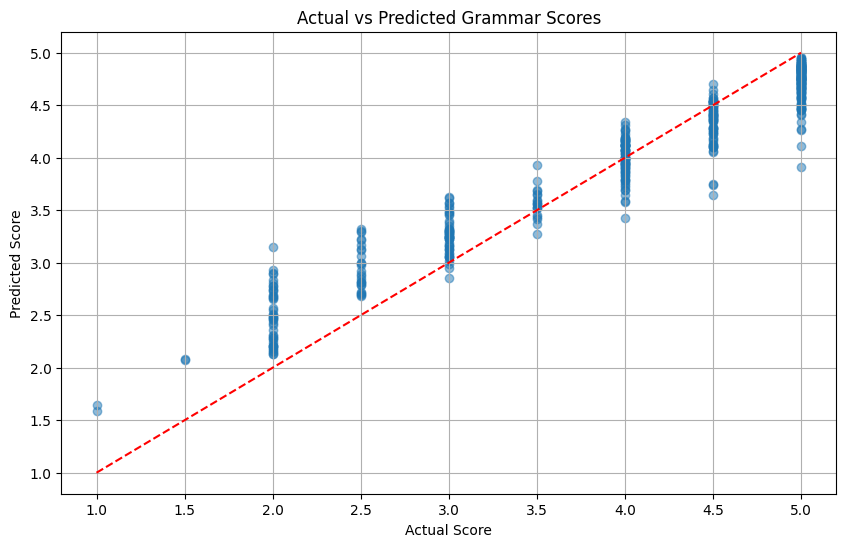

In [29]:
# Visualize predictions vs actuals
plt.figure(figsize=(10, 6))
plt.scatter(y_train, y_train_pred, alpha=0.5)
plt.plot([1, 5], [1, 5], 'r--')
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.title('Actual vs Predicted Grammar Scores')
plt.grid(True)
plt.show()

In [30]:
# Make predictions on test set
print("\nGenerating predictions for test set...")
test_pred = model.predict(X_test)


Generating predictions for test set...


In [31]:
# Clip predictions to valid range (1-5)
test_pred = np.clip(test_pred, 1, 5)

In [32]:
# Round to nearest 0.5 to match Likert scale
test_pred = np.round(test_pred * 2) / 2

In [33]:
# Create submission file
submission = pd.DataFrame({
    'filename': test_filenames,
    'label': test_pred
})

In [34]:
# Save submission
SUBMISSION_PATH = BASE_DIR / 'grammar_score_submission.csv'
submission.to_csv(SUBMISSION_PATH, index=False)
print(f"\nSubmission file saved as: {SUBMISSION_PATH}")



Submission file saved as: C:\Users\ADVIK\Downloads\shl-intern-hiring-assessment\grammar_score_submission.csv


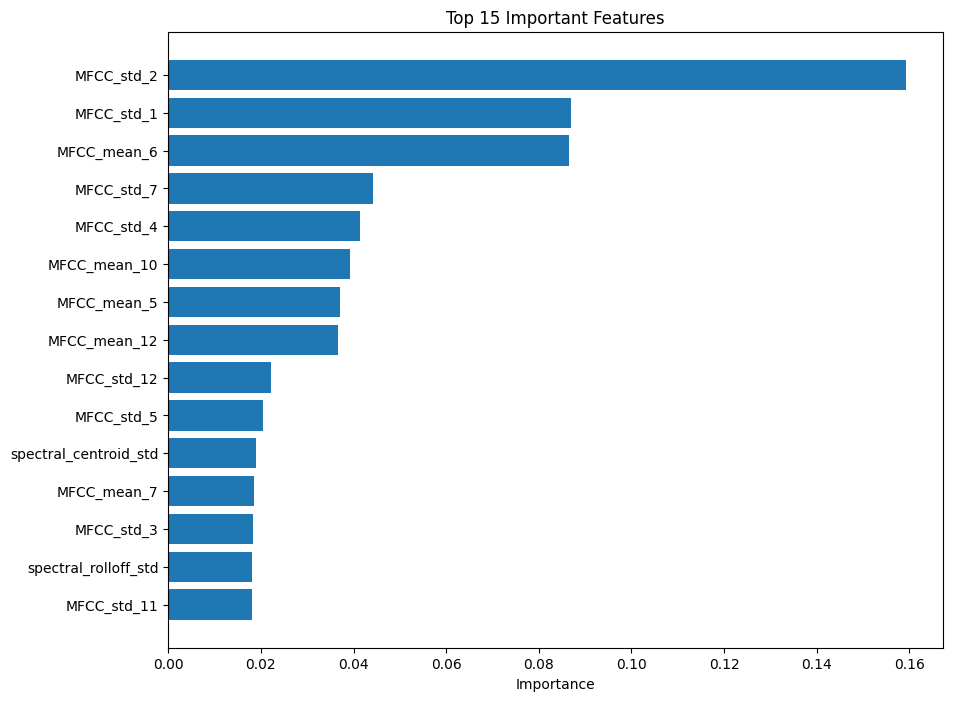

In [35]:
# Feature importance analysis
if hasattr(model.steps[-1][1], 'feature_importances_'):
    feature_importances = model.steps[-1][1].feature_importances_
    feature_names = [
        f'MFCC_mean_{i}' for i in range(N_MFCC)
    ] + [
        f'MFCC_std_{i}' for i in range(N_MFCC)
    ] + [
        'spectral_centroid_mean', 'spectral_centroid_std',
        'spectral_bandwidth_mean', 'spectral_bandwidth_std',
        'spectral_contrast_mean', 'spectral_contrast_std',
        'spectral_rolloff_mean', 'spectral_rolloff_std',
        'zcr_mean', 'zcr_std',
        'rms_mean', 'rms_std',
        'pitch_mean',
        'speech_rate'
    ]
    
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importances
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    plt.barh(importance_df['feature'][:15], importance_df['importance'][:15])
    plt.xlabel('Importance')
    plt.title('Top 15 Important Features')
    plt.gca().invert_yaxis()
    plt.show()

# BRIEF REPORT

-> Feature Extraction:

1. We use librosa to extract audio features that capture various aspects of speech quality

2. MFCCs (Mel-frequency cepstral coefficients) are particularly important for speech analysis

3. We also extract spectral features, pitch information, and estimate speech rate

4. Each audio file is standardized to 45 seconds by padding if necessary



-> Model Selection:

RandomForestRegressor is chosen because:

1. Handles the relatively small dataset well

2. Can capture non-linear relationships

3. Provides feature importance insights

4. Less prone to overfitting than deep learning with limited data

We use a pipeline with StandardScaler for feature normalization


-> Evaluation:

1. We split the training data to create a validation set

2. RMSE is used as it penalizes larger errors more heavily (appropriate for scoring)

3. We visualize predictions vs actuals to understand model behavior

4. Feature importance helps interpret what aspects of speech affect grammar scoring


-> Prediction:

1. Predictions are clipped to the valid range (1-5)

2. Rounded to nearest 0.5 to match the Likert scale format

3. Saved in the required submission format